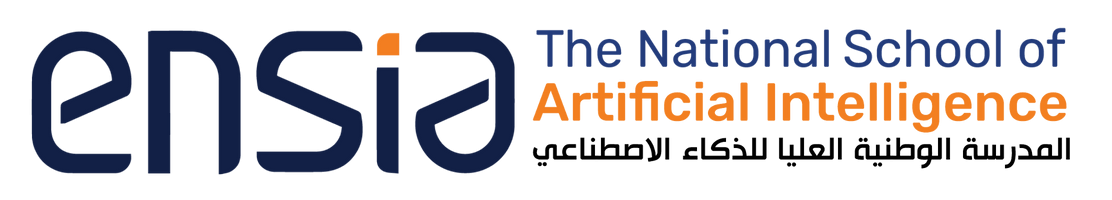

#**LAB 12: Case Study + Evaluation**

# Overview

>In our previous labs, we've taken a deep dive into the inner workings of foundational machine learning algorithms—building them from scratch and grounding each step in its mathematical underpinnings. In this lab, we'll shift gears to a model-selection case study, simulating a real-world pipeline:

1. **Data Preprocessing**:
Clean and transform our dataset to ensure fair, reliable training.

2. **Hyperparameter Tuning**:
For each candidate model, search for the optimal parameter set—using grid, random, and Bayesian strategies—to maximize performance.

3. **Resource-Conscious Tuning**:
Learn tricks for hyperparameter search when compute is limited (a practical compromise to avoid blindly trusting defaults or arbitrary choices).

4. **Performance Evaluation**:
Compare models using a variety of metrics—accuracy, F1, ROC-AUC, gain & lift curves—and visualize the results for clear, actionable insights.



In [41]:
# category_encoders is already installed in the DM_ENV environment
!pip install category_encoders


##**Mood Swings Classification Problem**:

- **Objective**: To predict the level of change in mood swings, which can range from subtle shifts to significant emotional changes.

- **Data Collection**:  gathering data from various sources such as social media posts, wearable devices tracking physiological signals, or self-reported mood logs.

- **Feature Engineering**: Identifying relevant features that can effectively represent the mood states and their changes. This could include text analysis for sentiment, biometric data for stress levels, or activity patterns.

- **Model Selection**: Choosing appropriate machine learning models that can handle the complexity of the data and provide accurate predictions. Models like Random Forest, Decision Trees, and Naive Bayes have been found effective.

- **Performance Metrics**: Evaluating the model using metrics such as precision, recall, F1 score, and accuracy to ensure it can reliably predict mood swings.


##**Business Analysis**:

- **Market Need**: There is a growing interest in mental health and well-being, with an increasing demand for tools that can monitor and predict mood swings for early intervention.

- **Application Areas**: The model can be used in healthcare for patient monitoring, in workplaces to enhance employee well-being, or in marketing to understand consumer behavior.

- **Challenges**: Ensuring privacy and ethical use of data, dealing with the imprecision of self-reported moods, and the need for personalized models.

- **Potential Impact**: Successful implementation can lead to improved mental health services, better user engagement in digital platforms, and insights into population mood trends.

---
# **PART I: MultiClass Classification**
---

## Import Libraries & Dataset

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import LinearSVC, SVC
#from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

from category_encoders import LeaveOneOutEncoder
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

import warnings
warnings.filterwarnings("ignore")


# LeaveOneOutEncoder: This is a specific encoder within the category_encoders library.
# LeaveOneOutEncoder is similar to target encoding but excludes the current row’s target when calculating
# the mean target for a level to reduce the effect of outliers2. It’s particularly useful to prevent data leakage
# in a machine learning model where the model might inadvertently learn from the target variable.

## Preprocessing

In [43]:
# Import the data
df = pd.read_csv('Mental Health Dataset.csv')

print(df.shape)

df.head()


(292364, 17)


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [44]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Timestamp                292364 non-null  str  
 1   Gender                   292364 non-null  str  
 2   Country                  292364 non-null  str  
 3   Occupation               292364 non-null  str  
 4   self_employed            287162 non-null  str  
 5   family_history           292364 non-null  str  
 6   treatment                292364 non-null  str  
 7   Days_Indoors             292364 non-null  str  
 8   Growing_Stress           292364 non-null  str  
 9   Changes_Habits           292364 non-null  str  
 10  Mental_Health_History    292364 non-null  str  
 11  Mood_Swings              292364 non-null  str  
 12  Coping_Struggles         292364 non-null  str  
 13  Work_Interest            292364 non-null  str  
 14  Social_Weakness          292364 non-null  str  

### **Handling duplicates**

In [45]:
# Checck number of duplicates
print(f"Number of duplicate rows : {df.duplicated().sum()}")


Number of duplicate rows : 2313


In [46]:
#
df.drop_duplicates(inplace=True)


In [47]:
print("shapee data is", df.shape, "instead of (292364, 17)")


shapee data is (290051, 17) instead of (292364, 17)


### **Handling Missing Values**

In [48]:
df.isnull().sum()


Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5193
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [49]:
df.dropna(inplace=True)


In [50]:
print ("shapee data is", df.shape, "instead of (290051, 17)")


shapee data is (284858, 17) instead of (290051, 17)


### **Convert categorical data to numerical values**

>To effectively preprocess categorical features in our dataset, we apply different encoding strategies based on the nature of each variable:

- **LabelEncoder** is used for binary categorical variables because it efficiently maps the two possible values to 0 and 1, preserving minimal memory usage and avoiding unnecessary dimensionality increase.

- **get_dummies** is applied to categorical variables with multiple unordered classes. It creates one-hot encoded features, which are appropriate for models that don't assume ordinal relationships among categories and can handle increased dimensionality without issue.

- **LeaveOneOutEncoder** is selected for the countries feature, which has a high cardinality (many unique values). This method encodes each category using the mean target value of all other observations with the same category, thus reducing dimensionality and helping the model generalize better, especially when some categories appear infrequently.

In [51]:
# LabelEncoder for binary categorical variables,
le = LabelEncoder()
# TODOS: Convert the following columns using labelEncoder
df["Gender"] = le.fit_transform(df["Gender"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["family_history"] = le.fit_transform(df["family_history"])
df["treatment"] = le.fit_transform(df["treatment"])
df["Coping_Struggles"] = le.fit_transform(df["Coping_Struggles"])

df.head()


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,8/27/2014 11:37,0,United States,Corporate,0,1,1,1-14 days,Yes,No,Yes,Medium,0,No,Yes,Maybe,Yes
4,8/27/2014 11:43,0,United States,Corporate,0,1,1,1-14 days,Yes,No,Yes,Medium,0,No,Yes,No,Yes
5,8/27/2014 11:49,0,Poland,Corporate,0,0,1,1-14 days,Yes,No,Yes,Medium,0,No,Yes,Maybe,Not sure
6,8/27/2014 11:51,0,Australia,Corporate,0,1,1,1-14 days,Yes,No,Yes,Medium,0,No,Yes,No,Not sure
7,8/27/2014 11:52,0,United States,Corporate,0,0,0,1-14 days,Yes,No,Yes,Medium,0,No,Yes,No,No


In [52]:
y_encoded = LabelEncoder().fit_transform(df["target"] if 'target' in df else df["Mood_Swings"] if 'Mood_Swings' in df else df.iloc[:,-1])
df["target"] = y_encoded
data = pd.get_dummies(df, columns=["Occupation", "Days_Indoors", "Growing_Stress","Changes_Habits", "Mental_Health_History", "Work_Interest", "Social_Weakness","mental_health_interview", "care_options"])
          # The columns are : ["Occupation", "Days_Indoors", "Growing_Stress","Changes_Habits", "Mental_Health_History", "Work_Interest", "Social_Weakness","mental_health_interview", "care_options"]

# Convert any boolean dummy columns to integers for downstream estimators
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

# Display the first five instances
data.head()


,Timestamp,Gender,Country,self_employed,family_history,treatment,Mood_Swings,Coping_Struggles,target,Occupation_Business,...,Work_Interest_Yes,Social_Weakness_Maybe,Social_Weakness_No,Social_Weakness_Yes,mental_health_interview_Maybe,mental_health_interview_No,mental_health_interview_Yes,care_options_No,care_options_Not sure,care_options_Yes
3,8/27/2014 11:37,0,United States,0,1,1,Medium,0,2,0,...,0,0,0,1,1,0,0,0,0,1
4,8/27/2014 11:43,0,United States,0,1,1,Medium,0,2,0,...,0,0,0,1,0,1,0,0,0,1
5,8/27/2014 11:49,0,Poland,0,0,1,Medium,0,2,0,...,0,0,0,1,1,0,0,0,1,0
6,8/27/2014 11:51,0,Australia,0,1,1,Medium,0,2,0,...,0,0,0,1,0,1,0,0,1,0
7,8/27/2014 11:52,0,United States,0,0,0,Medium,0,2,0,...,0,0,0,1,0,1,0,1,0,0


In [53]:
data['target']

3         2
4         2
5         2
6         2
7         2
         ..
292359    1
292360    1
292361    1
292362    1
292363    1
Name: target, Length: 284858, dtype: int64

In [54]:
# Drop Timestamp column (not informative for modelling)
data.drop(columns=['Timestamp'], inplace=True, errors='ignore')
data.head()


,Gender,Country,self_employed,family_history,treatment,Mood_Swings,Coping_Struggles,target,Occupation_Business,Occupation_Corporate,...,Work_Interest_Yes,Social_Weakness_Maybe,Social_Weakness_No,Social_Weakness_Yes,mental_health_interview_Maybe,mental_health_interview_No,mental_health_interview_Yes,care_options_No,care_options_Not sure,care_options_Yes
3,0,United States,0,1,1,Medium,0,2,0,1,...,0,0,0,1,1,0,0,0,0,1
4,0,United States,0,1,1,Medium,0,2,0,1,...,0,0,0,1,0,1,0,0,0,1
5,0,Poland,0,0,1,Medium,0,2,0,1,...,0,0,0,1,1,0,0,0,1,0
6,0,Australia,0,1,1,Medium,0,2,0,1,...,0,0,0,1,0,1,0,0,1,0
7,0,United States,0,0,0,Medium,0,2,0,1,...,0,0,0,1,0,1,0,1,0,0


In [55]:
# LeaveOneOutEncoder for the Country feature, encoded against the binary 'High mood swings' indicator
leave_encoder = LeaveOneOutEncoder()

# Build a binary target: 1 if the original Mood_Swings was 'High', else 0
high_target = (data['Mood_Swings'] == 'High').astype(int)

# Fit-transform the Country column with leave-one-out encoding using the High indicator
data['Country'] = leave_encoder.fit_transform(data['Country'], high_target).fillna(0)

# Display the first five instances
data.head()


,Gender,Country,self_employed,family_history,treatment,Mood_Swings,Coping_Struggles,target,Occupation_Business,Occupation_Corporate,...,Work_Interest_Yes,Social_Weakness_Maybe,Social_Weakness_No,Social_Weakness_Yes,mental_health_interview_Maybe,mental_health_interview_No,mental_health_interview_Yes,care_options_No,care_options_Not sure,care_options_Yes
3,0,0.312640,0,1,1,Medium,0,2,0,1,...,0,0,0,1,1,0,0,0,0,1
4,0,0.312640,0,1,1,Medium,0,2,0,1,...,0,0,0,1,0,1,0,0,0,1
5,0,0.320732,0,0,1,Medium,0,2,0,1,...,0,0,0,1,1,0,0,0,1,0
6,0,0.314652,0,1,1,Medium,0,2,0,1,...,0,0,0,1,0,1,0,0,1,0
7,0,0.312640,0,0,0,Medium,0,2,0,1,...,0,0,0,1,0,1,0,1,0,0


### **Split (train/test)**

In [56]:
from sklearn.model_selection import train_test_split

# Get the composed target
y = data['target']
# the input — drop the target column and the original Mood_Swings text column
X = data.drop(columns=['target', 'Mood_Swings'])

# Train/test split with shuffling, fixed random_state, 30% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y, random_state=42
)
print('X_train shape:', X_train.shape, 'X_test shape:', X_test.shape)


X_train shape: (199400, 37) X_test shape: (85458, 37)


---
## 🔍 **Hyperparameter-Search Wrappers**
---

>Before deploying any model, it’s crucial to choose its hyperparameters (e.g. regularization strength, tree depth, learning-rate schedules) in a principled way. Three widely-used “wrapper” strategies are:

>1. **Grid Search**: We exhaustively evaluate a Cartesian “grid” of all combinations in a predefined parameter mesh.
  * How it works:
    * Define a discrete set of values for each hyperparameter.
    * Train & cross-validate the model on every possible combination.
    * Select the combination yielding the best validation score.
  * Pros:
    * Guarantees finding the best configuration within the specified grid.
    * Easy to implement and reason about.
  * Cons:
    * Expensive: number of fits grows multiplicatively with the number of parameters and grid points.
    * Wastes effort exploring unpromising areas of the space.
2. **Random Search**: Rather than exhaustively covering every grid point, we sample a fixed number of random combinations from the hyperparameter space.
  * How it works:
    * Specify ranges or distributions for each hyperparameter.
    * Randomly draw $N$ combinations and cross-validate each.
    * Pick the best performing draw.
  * Pros:
    * Much faster than grid when the search space is large—budgeted to a fixed number of trials.
    * Capable of discovering good hyperparameters even if they lie off a regular grid.
    * Surprising often that a handful of well-chosen random samples can beat a coarse grid.
  * Cons:
    * No guarantee of covering the entire space (might “miss” the optimum).
    * Performance can vary from run to run unless seeded.
3. **Bayesian Optimization**: Models the validation score as a function of the hyperparameters and uses that surrogate to guide the search toward promising areas.
  * How it works:
    * Fit a probabilistic surrogate (e.g. Gaussian Process) on observed (hyperparams → validation score) pairs.
    * Use an acquisition function (e.g. expected improvement) to pick the next hyperparameter set.
    * Evaluate, update the surrogate, and repeat.
  * Pros
    * Sample-efficient: quickly focuses on high-performing regions.
    * Generally finds better solutions with fewer evaluations than random or grid.
    * Can handle continuous, discrete, and even conditional parameter spaces.
  * Cons
    * More complex to implement and tune (choice of surrogate, acquisition).
    * Overhead of fitting the surrogate can dominate if individual model fits are very cheap.
    * Can struggle in extremely high-dimensional hyperparameter spaces.

  ---
**Small search spaces / guaranteed optimum → Grid Search**

**Large spaces / strict compute budget → Random Search**

**High cost per evaluation / need sample efficiency → Bayesian Optimization**

---

In [57]:
# scikit-optimize is already installed in DM_ENV
# !pip install scikit-optimize


In [58]:
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
try:
    from skopt import BayesSearchCV
except ImportError:
    BayesSearchCV = None

def grid_searcher(estimator, param_grid, **kwargs):
    return GridSearchCV(estimator, param_grid, **kwargs)

def random_searcher(estimator, param_dist, n_iter=6, **kwargs):
    return RandomizedSearchCV(estimator, param_dist, n_iter=n_iter, **kwargs)

def bayes_searcher(estimator, search_spaces, n_iter=6, **kwargs):
    if BayesSearchCV is None:
        raise ImportError("`pip install scikit-optimize` to use Bayesian Search")
    return BayesSearchCV(estimator, search_spaces, n_iter=n_iter, **kwargs)

def time_and_score(searcher, X, y, metric="accuracy"):
    """Fit searcher, return best score and elapsed time."""
    t0 = time.time()
    searcher.fit(X, y)
    elapsed = time.time() - t0
    best = searcher.best_score_
    return {"best_score": best, "time_sec": elapsed, "best_params": searcher.best_params_}


### Sampling

> For this exercise, to keep runtimes reasonable, we’ll work with just $1\%$ of the data—stratified by class to preserve the original label distribution.

In [59]:
# Stratified 1% sample of the training set to keep search time short
_, X_small, _, y_small = train_test_split(
    X_train, y_train, test_size=0.01, stratify=y_train, random_state=42
)
X_small.shape


(1994, 37)

>First, let's experiment with our sampled dataset using the previously defined search wrappers. In this cell, we'll apply them to a Logistic Regression model.

**Note:** We use two separate dictionaries in the parameter list to ensure valid combinations. For example, the `LBFGS` solver is not compatible with the `L1` penalty, so we explicitly separate such cases to avoid invalid configurations.

---
Now, let’s apply these tuning strategies to three different models and inspect each one’s optimal hyperparameters.
---

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression # Ensure import
from sklearn.neural_network import MLPClassifier    # Ensure import

# Define MLP parameters
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [1e-4, 1e-3],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [200],
    'early_stopping': [True]
}

# Define Logistic Regression parameters (resolving the NameError)
# We use a list of dictionaries to handle solver-specific parameter compatibility
grid_params = [
    {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.1, 1, 5, 10]},
    {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.1, 1, 5, 10]}
]

models = {
    "Logistic": (LogisticRegression(solver="liblinear", max_iter=1000),   grid_params),
    "Tree":     (DecisionTreeClassifier(),               {"max_depth":[3,5,7]}),
    "SVM":      (SVC(kernel="rbf", probability=True, max_iter=100),      {"C":[0.1,1,10], "gamma":["scale","auto"]}),
    "MLP":      (MLPClassifier(random_state=42), mlp_params)
}

def tune_model(name, model, param_space, search_type="random"):
    """Fit one model with one of {grid, random, bayes} search."""
    if search_type == "grid":
        search = grid_searcher(model, param_space, cv=3, scoring='f1_macro', n_jobs=-1)
    elif search_type == "random":
        search = random_searcher(model, param_space, n_iter=5, cv=3, scoring='f1_macro', n_jobs=-1)
    elif search_type == "bayes":
        search = bayes_searcher(model, param_space, n_iter=5, cv=3, scoring='f1_macro', n_jobs=-1)
    else:
        raise ValueError(f"Unknown search_type={search_type!r}")

    t0 = time.time()
    search.fit(X_small, y_small)
    elapsed = time.time() - t0

    return {
        "model": name,
        "search": search_type,
        "best_score": search.best_score_,
        "time_sec": elapsed,
        "best_params": dict(search.best_params_),
    }

all_results = []
for m_name, (m_obj, m_params) in models.items():
    print(f"------------{m_name}-------------")
    for method in ["grid"]:  # You can add : "random", "bayes" to the list
        info = tune_model(m_name, m_obj, m_params, search_type=method)
        all_results.append(info)

import pandas as pd
pd.DataFrame(all_results)


------------Logistic-------------
------------Tree-------------
------------SVM-------------
------------MLP-------------


,model,search,best_score,time_sec,best_params
0,Logistic,grid,0.412421,2.861822,"{'C': 5, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,Tree,grid,0.717504,0.115872,{'max_depth': 7}
2,SVM,grid,0.558383,0.422215,"{'C': 10, 'gamma': 'scale'}"
3,MLP,grid,0.545089,4.815432,"{'activation': 'relu', 'alpha': 0.001, 'early_..."


---
## **Model Selection**
---

>Model selection is the process of comparing multiple duly–tuned models using consistent evaluation metrics (e.g., accuracy, F1-score, AUC) and then choosing the one that best meets our performance and business requirements.

---
**Note:** Use the sampled dataset only if training on the full dataset is too time-consuming. However, in practical scenarios, it is essential to perform training on the full training set to ensure optimal model performance.
---

In [61]:
# Stratified subsample of the training set used for the final fit.
# We use 5% (~10k rows) to keep SVM training tractable in the lab; the lab text suggests
# using a smaller fraction whenever the full dataset would be too slow.
_, X_large, _, y_large = train_test_split(
    X_train, y_train, test_size=0.05, stratify=y_train, random_state=42
)

# Also build a smaller, stratified test slice for fast evaluation of slow models (SVM in particular)
_, X_large_test, _, y_large_test = train_test_split(
    X_test, y_test, test_size=0.05, stratify=y_test, random_state=42
)
X_large.shape, X_large_test.shape


((9970, 37), (4273, 37))

In [62]:
from sklearn.base import clone
import pandas as pd

# 1) Turn your tuning results into a DataFrame
df = pd.DataFrame(all_results)

# 2) For each model name, pick the first best_params you see
best_param_map = (
    df
    .groupby('model', as_index=False)
    .first()[['model', 'best_params']]
    .set_index('model')['best_params']
    .to_dict()
)

# 3) Refit each base estimator with its chosen hyperparameters on the (sampled) train set
final_models = {}

for model_name, (base_estimator, _) in models.items():
    print(f"--------------{model_name}------------------")
    params = best_param_map[model_name]
    clf = clone(base_estimator).set_params(**params)
    clf.fit(X_large, y_large)
    final_models[model_name] = clf
    print(f"Fitted {model_name} with params: {params}")


--------------Logistic------------------
Fitted Logistic with params: {'C': 5, 'penalty': 'l2', 'solver': 'lbfgs'}
--------------Tree------------------
Fitted Tree with params: {'max_depth': 7}
--------------SVM------------------
Fitted SVM with params: {'C': 10, 'gamma': 'scale'}
--------------MLP------------------
Fitted MLP with params: {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 200, 'solver': 'adam'}


---
## **Metrics: Predict and Evaluate**
---

> To identify the best-performing model, we compare all selected models using a set of evaluation metrics that capture different aspects of performance. The metrics used in this analysis are:

- **Accuracy:** Measures the proportion of correct predictions over the total number of instances.

- **ROC-AUC Score:** Evaluates the model's ability to distinguish between classes by measuring the area under the Receiver Operating Characteristic curve.

- **Classification Report:** Provides detailed metrics including *Precision* (how many selected items are relevant), *Recall* (how many relevant items are selected), and *F1 Score* (harmonic mean of precision and recall) for each class.

- **Kolmogorov-Smirnov (K-S) Statistic:** Quantifies the maximum difference between the cumulative distributions of predicted probabilities for the positive and negative classes, helping assess model separation capability.

- **Gain:** Shows the cumulative $\%$ of true positives captured as you go down the ranked prediction list.

- **Lift:** Shows how much better your model is compared to random guessing at capturing positives.

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    roc_curve,
    auc,
    accuracy_score
)
from scipy.stats import ks_2samp
from sklearn.preprocessing import label_binarize

def multiclass_ks_score(y_true, y_proba, classes):
    """Per-class KS statistic comparing predicted-probability distributions of
    the positive class vs. the rest (one-vs-rest)."""
    ks_scores = {}
    y_true = np.asarray(y_true)
    for i, cls in enumerate(classes):
        # boolean mask of ground-truth examples that belong to the chosen class
        mask = (y_true == cls)
        ks_stat, _ = ks_2samp(y_proba[mask, i], y_proba[~mask, i])
        ks_scores[cls] = ks_stat
    return ks_scores

def plot_multiclass_roc_auc(y_true, y_proba, class_names=None, average="macro", title=None):
    classes = sorted(set(y_true))
    y_bin = label_binarize(y_true, classes=classes)

    if class_names is None:
        class_names = [f"Class {i}" for i in classes]

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(7, 5))

    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    if title:
        plt.title(title)
    else:
        plt.title("Multiclass ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return roc_auc_score(y_bin, y_proba, average=average, multi_class="ovr")

def compute_gain_lift(y_true, y_proba, class_names):
    n_classes = y_proba.shape[1]
    y_true = np.array(y_true)

    for i in range(n_classes):
        # One-vs-rest for class i
        y_bin = (y_true == i).astype(int)
        scores = y_proba[:, i]

        df = pd.DataFrame({
            'y_true': y_bin,
            'score': scores
        }).sort_values('score', ascending=False).reset_index(drop=True)

        df['cum_positives'] = df['y_true'].cumsum()
        total_positives = df['y_true'].sum()
        if total_positives == 0:
            continue
        df['gain'] = df['cum_positives'] / total_positives
        df['percentage'] = np.arange(1, len(df)+1) / len(df)
        df['lift'] = df['gain'] / df['percentage']

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(df['percentage'], df['gain'], label=f'Class {class_names[i]}')
        plt.plot([0,1], [0,1], 'k--', label='Baseline')
        plt.xlabel('Percentage of Sample')
        plt.ylabel('Gain')
        plt.title(f'Gain Chart for Class {class_names[i]}')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(df['percentage'], df['lift'], label=f'Class {class_names[i]}')
        plt.axhline(1, color='k', linestyle='--')
        plt.xlabel('Percentage of Sample')
        plt.ylabel('Lift')
        plt.title(f'Lift Chart for Class {class_names[i]}')
        plt.legend()

        plt.tight_layout()
        plt.show()

performances = {}


> **Logistic Regression model**

Accuracy for Logistic Regression: 0.44348233091504796


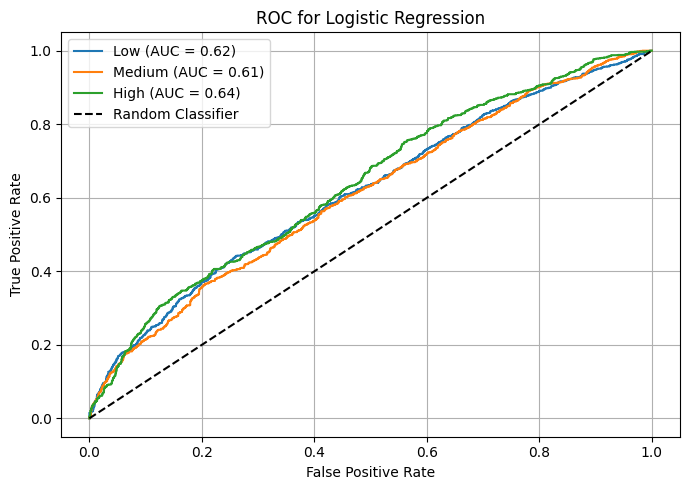

ROC-AUC for Logistic Regression: 0.6214641178276414
-----------------------------------___Confusion Matrix___Logistic_Regression-----------------------------------


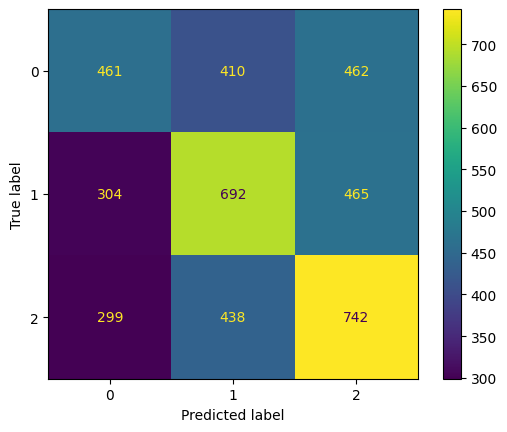


Logistic Regression classification report:
               precision    recall  f1-score   support

           0       0.43      0.35      0.38      1333
           1       0.45      0.47      0.46      1461
           2       0.44      0.50      0.47      1479

    accuracy                           0.44      4273
   macro avg       0.44      0.44      0.44      4273
weighted avg       0.44      0.44      0.44      4273


Logistic Regression K-S statistic:
 {np.int64(0): np.float64(0.181656383483626), np.int64(1): np.float64(0.15968013295906952), np.int64(2): np.float64(0.1920884267117357)}


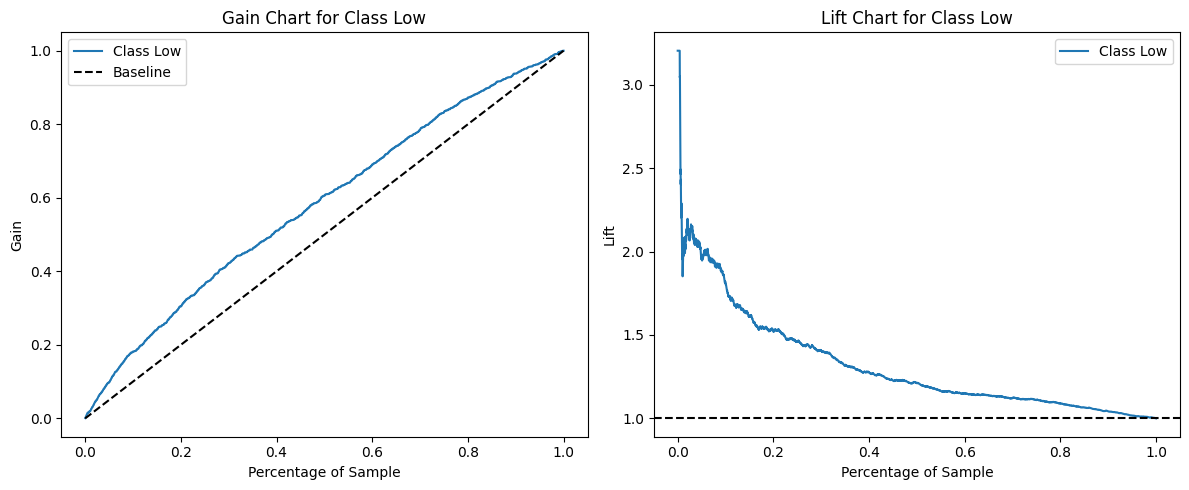

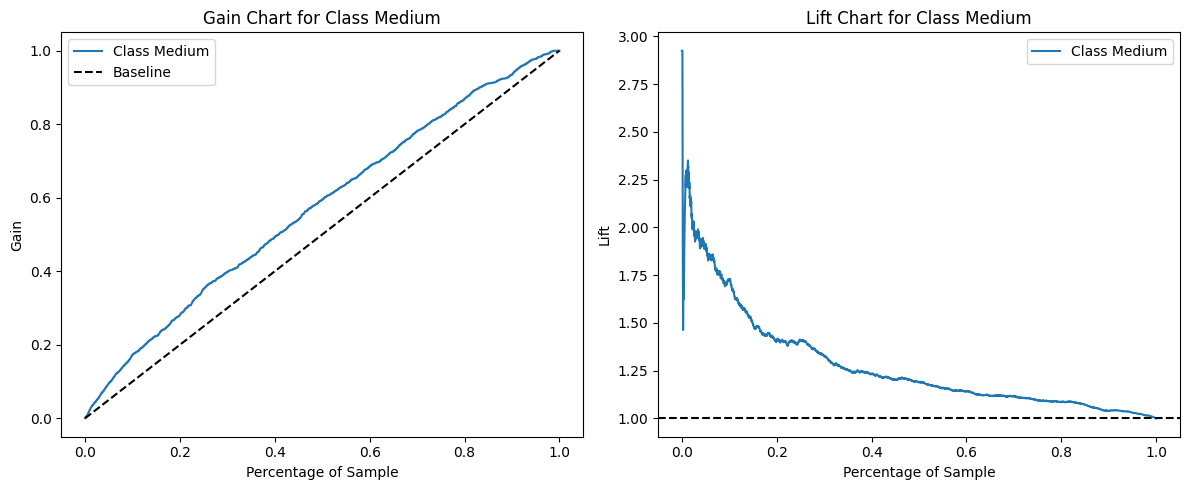

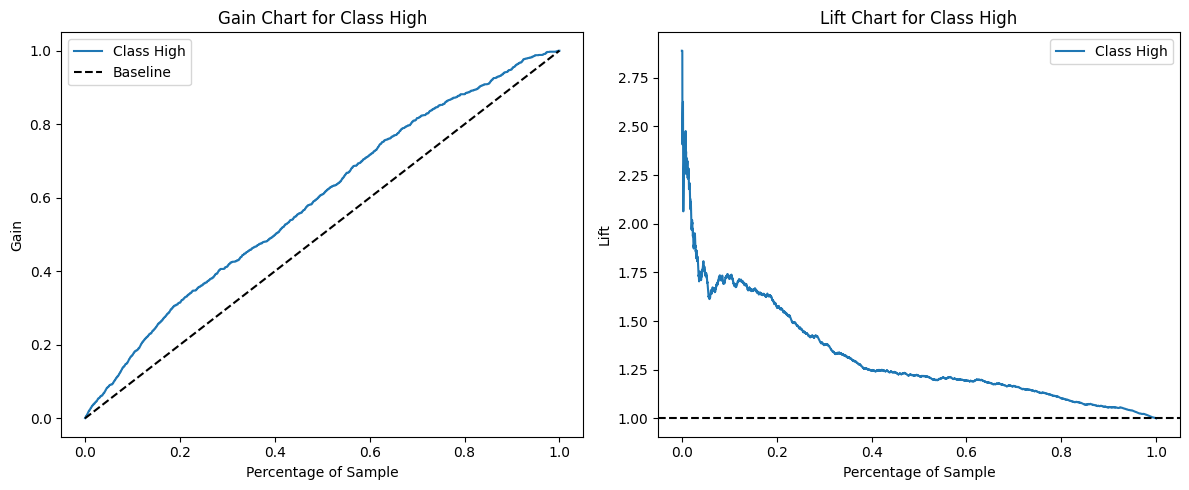

In [64]:
# Logistic Regression
logistic_model = final_models['Logistic']
# 4) Evaluate on the held-out test set (stratified 5% slice for speed)
y_pred_logistic = logistic_model.predict(X_large_test)
y_proba_logistic = logistic_model.predict_proba(X_large_test)

# Accuracy
acc = accuracy_score(y_large_test, y_pred_logistic)
print(f'Accuracy for Logistic Regression: {acc}')

# ROC-AUC
lg_auc = plot_multiclass_roc_auc(y_large_test, y_proba_logistic, class_names=['Low', 'Medium', 'High'], title='ROC for Logistic Regression')
print(f'ROC-AUC for Logistic Regression: {lg_auc}')

# Confusion Matrix
print('-----------------------------------___Confusion Matrix___Logistic_Regression-----------------------------------')
ConfusionMatrixDisplay.from_estimator(logistic_model, X_large_test, y_large_test)
plt.show()

# Classification report
LR_class_reports = classification_report(y_large_test, y_pred_logistic)
print(f'\nLogistic Regression classification report:\n', LR_class_reports)

# KS statistic
LR_ks_result = multiclass_ks_score(y_large_test, y_proba_logistic, classes=logistic_model.classes_)
print(f'\nLogistic Regression K-S statistic:\n', LR_ks_result)

# Gain & Lift charts
gain_lift_LR = compute_gain_lift(y_large_test, y_proba_logistic, class_names=['Low', 'Medium', 'High'])

performances['logistic'] = {
    'accuracy': acc,
    'roc_auc': lg_auc,
    'classification_report': LR_class_reports,
    'K-S statistic': LR_ks_result,
    'gain_lift': gain_lift_LR
}


> **Decision Tree model**

Accuracy for Decision Tree: 0.7406974022934706


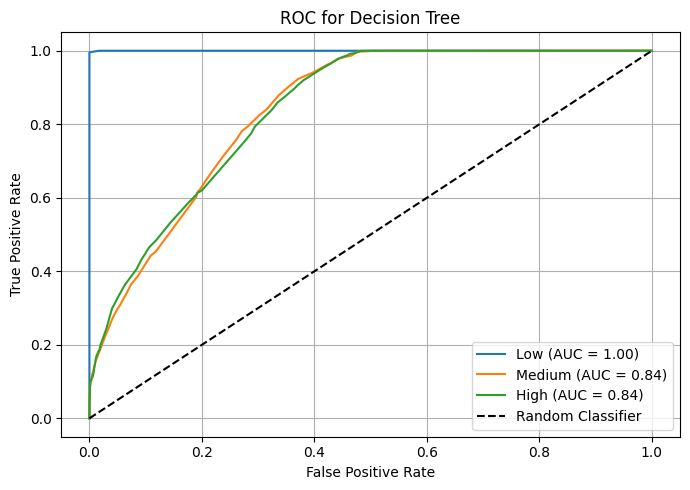

ROC-AUC for Decision Tree: 0.8937351685788891
-----------------------------------___Confusion Matrix___Decision_Tree-----------------------------------


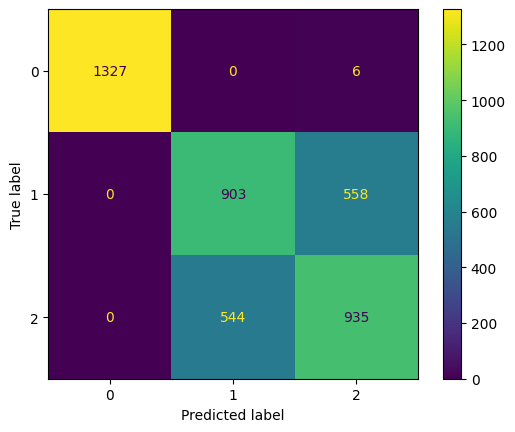


Decision Tree classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1333
           1       0.62      0.62      0.62      1461
           2       0.62      0.63      0.63      1479

    accuracy                           0.74      4273
   macro avg       0.75      0.75      0.75      4273
weighted avg       0.74      0.74      0.74      4273


Decision Tree K-S statistic:
 {np.int64(0): np.float64(0.9954988747186797), np.int64(1): np.float64(0.552074175115351), np.int64(2): np.float64(0.5390424182409617)}


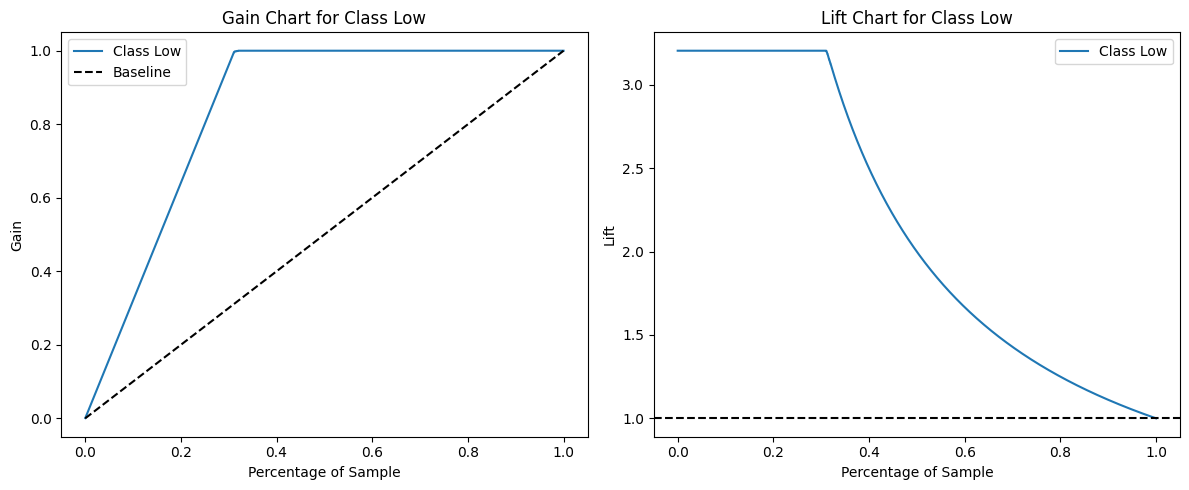

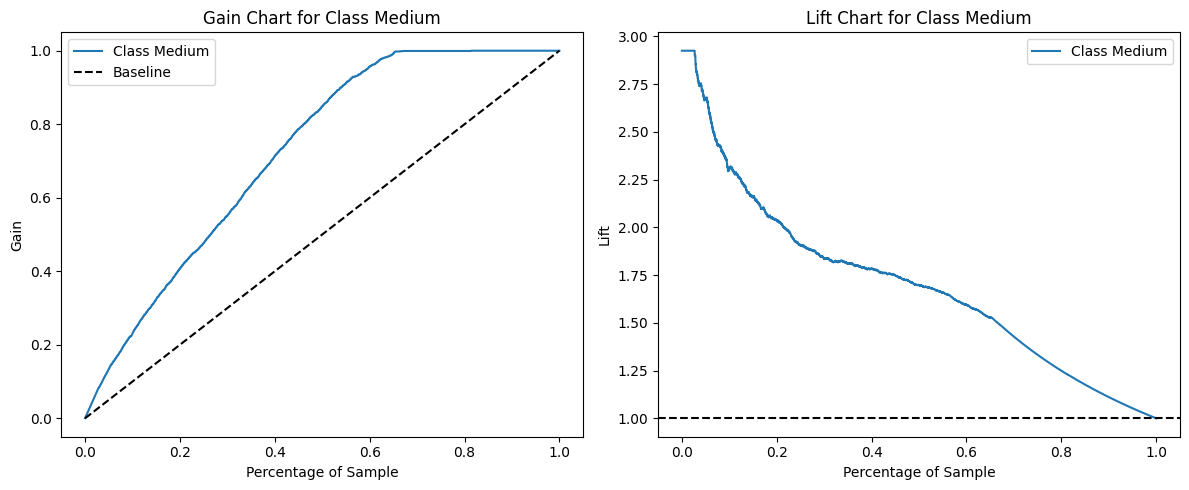

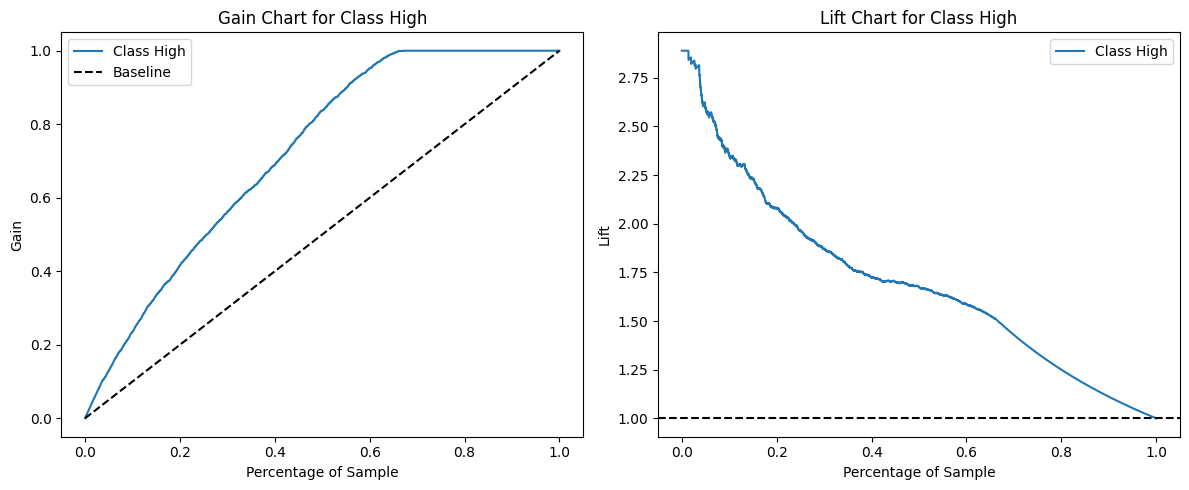

In [65]:
# Decision Tree
DT_model = final_models['Tree']
# 4) Evaluate on the held-out test set
y_pred_DT = DT_model.predict(X_large_test)
y_proba_DT = DT_model.predict_proba(X_large_test)

# Accuracy
acc_DT = accuracy_score(y_large_test, y_pred_DT)
print(f'Accuracy for Decision Tree: {acc_DT}')

# ROC-AUC
auc_DT = plot_multiclass_roc_auc(y_large_test, y_proba_DT, class_names=['Low', 'Medium', 'High'], title='ROC for Decision Tree')
print(f'ROC-AUC for Decision Tree: {auc_DT}')

# Confusion Matrix
print('-----------------------------------___Confusion Matrix___Decision_Tree-----------------------------------')
ConfusionMatrixDisplay.from_estimator(DT_model, X_large_test, y_large_test)
plt.show()

# Classification report
DT_class_reports = classification_report(y_large_test, y_pred_DT)
print(f'\nDecision Tree classification report:\n', DT_class_reports)

# KS statistic
DT_ks_result = multiclass_ks_score(y_large_test, y_proba_DT, classes=DT_model.classes_)
print(f'\nDecision Tree K-S statistic:\n', DT_ks_result)

# Gain & Lift charts
gain_lift_DT = compute_gain_lift(y_large_test, y_proba_DT, class_names=['Low', 'Medium', 'High'])

performances['Tree'] = {
    'accuracy': acc_DT,
    'roc_auc': auc_DT,
    'classification_report': DT_class_reports,
    'K-S statistic': DT_ks_result,
    'gain_lift': gain_lift_DT
}


> **Support Vector Machine model**

Accuracy for SVM: 0.465714954364615


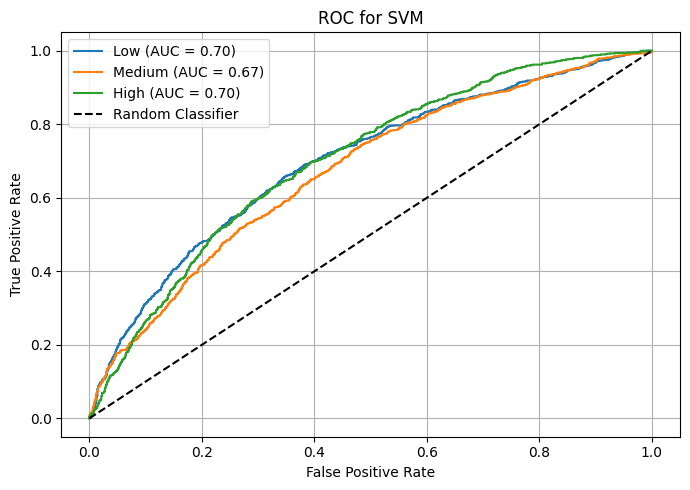

ROC-AUC for SVM: 0.6919327598349763
-----------------------------------___Confusion Matrix___SVM-----------------------------------


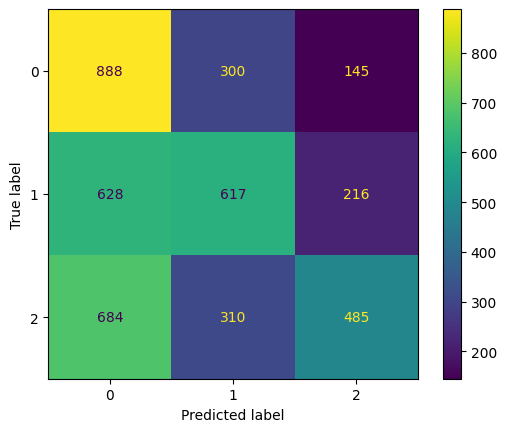


 SVM classification report:
               precision    recall  f1-score   support

           0       0.40      0.67      0.50      1333
           1       0.50      0.42      0.46      1461
           2       0.57      0.33      0.42      1479

    accuracy                           0.47      4273
   macro avg       0.49      0.47      0.46      4273
weighted avg       0.50      0.47      0.46      4273


 SVM K-S statistic:
 {np.int64(0): np.float64(0.3102954310006073), np.int64(1): np.float64(0.2615626001014524), np.int64(2): np.float64(0.30339184275393566)}


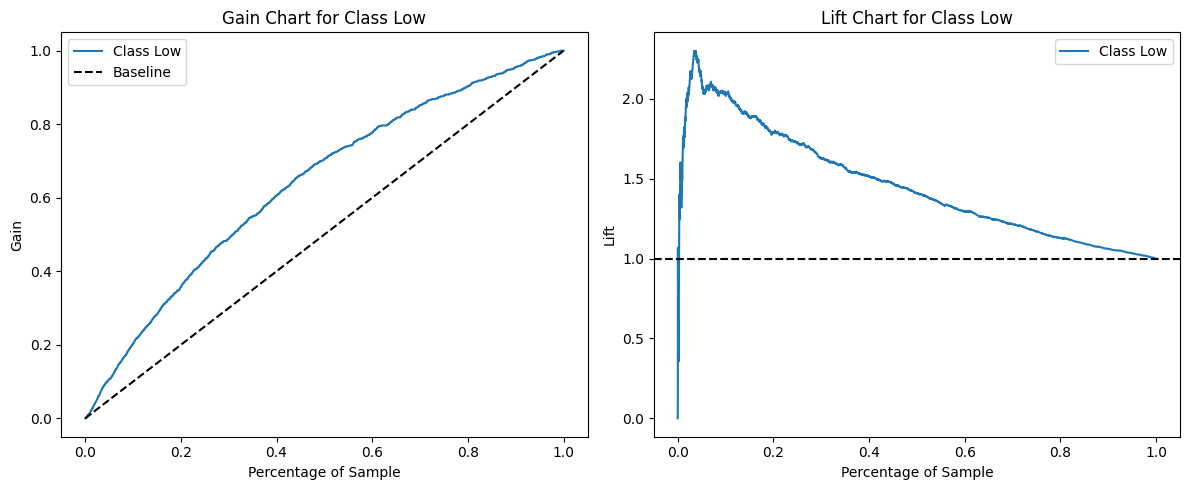

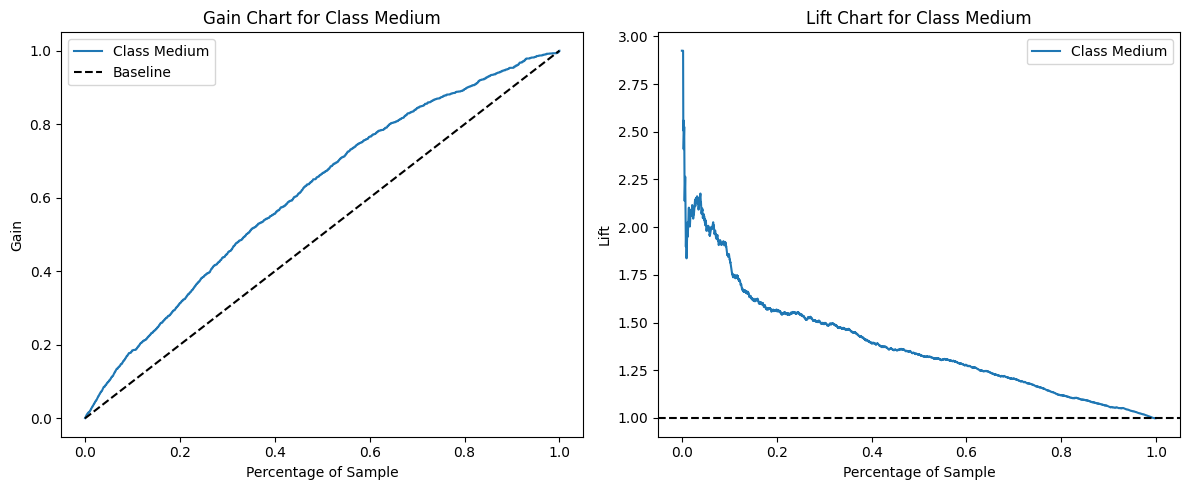

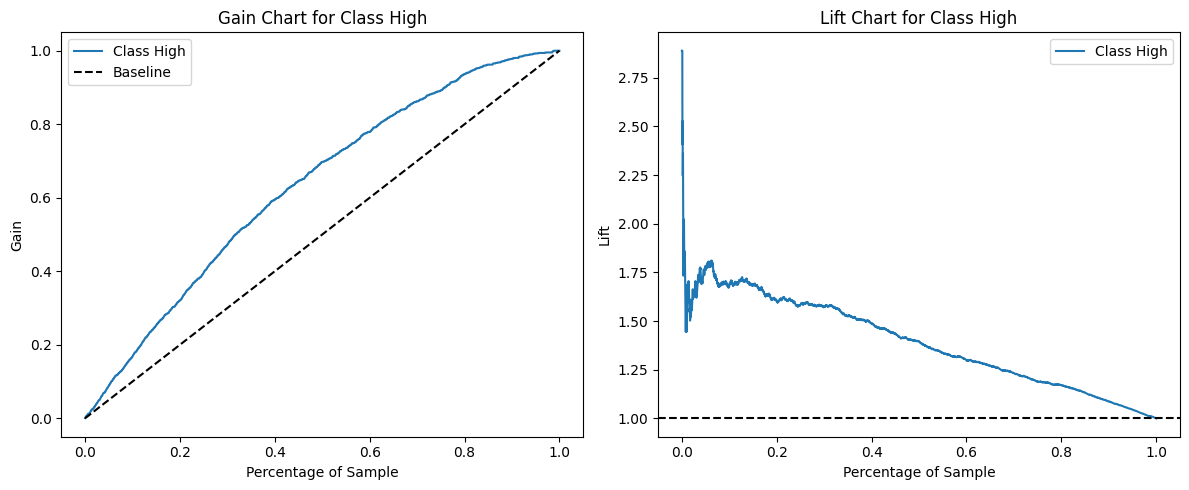

In [66]:
# SVM
SVM_model = final_models['SVM']
# 4) Evaluate on the held-out test set
y_pred_SVM = SVM_model.predict(X_large_test)
y_proba_SVM = SVM_model.predict_proba(X_large_test)

# Accuracy
acc_SVM = accuracy_score(y_large_test, y_pred_SVM)
print(f'Accuracy for SVM: {acc_SVM}')

# ROC-AUC
auc_SVM = plot_multiclass_roc_auc(y_large_test, y_proba_SVM, class_names=['Low', 'Medium', 'High'], title='ROC for SVM')
print(f'ROC-AUC for SVM: {auc_SVM}')

# Confusion Matrix
print('-----------------------------------___Confusion Matrix___SVM-----------------------------------')
ConfusionMatrixDisplay.from_estimator(SVM_model, X_large_test, y_large_test)
plt.show()

# Classification report
SVM_class_reports = classification_report(y_large_test, y_pred_SVM)
print(f'\n SVM classification report:\n', SVM_class_reports)

# KS statistic
SVM_ks_result = multiclass_ks_score(y_large_test, y_proba_SVM, classes=SVM_model.classes_)
print(f'\n SVM K-S statistic:\n', SVM_ks_result)

# Gain & Lift charts
gain_lift_SVM = compute_gain_lift(y_large_test, y_proba_SVM, class_names=['Low', 'Medium', 'High'])

performances['SVM'] = {
    'accuracy': acc_SVM,
    'roc_auc': auc_SVM,
    'classification_report': SVM_class_reports,
    'K-S statistic': SVM_ks_result,
    'gain_lift': gain_lift_SVM
}


> **Multilayer Perceptron model**

Accuracy for MLP: 0.9391528200327639


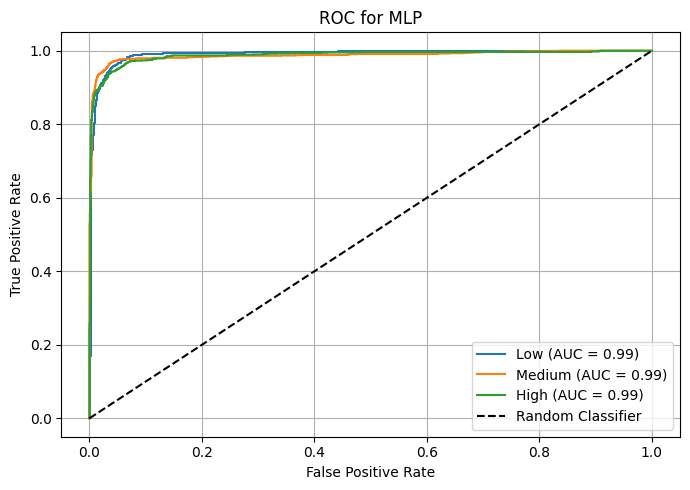

ROC-AUC for MLP: 0.9881928399278349
-----------------------------------___Confusion Matrix___MLP-----------------------------------


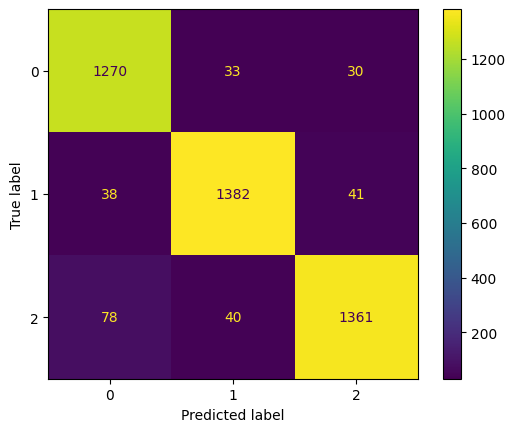


 MLP classification report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      1333
           1       0.95      0.95      0.95      1461
           2       0.95      0.92      0.94      1479

    accuracy                           0.94      4273
   macro avg       0.94      0.94      0.94      4273
weighted avg       0.94      0.94      0.94      4273


 MLP K-S statistic:
 {np.int64(0): np.float64(0.9158126266260442), np.int64(1): np.float64(0.9298861435735963), np.int64(2): np.float64(0.9041530121292464)}


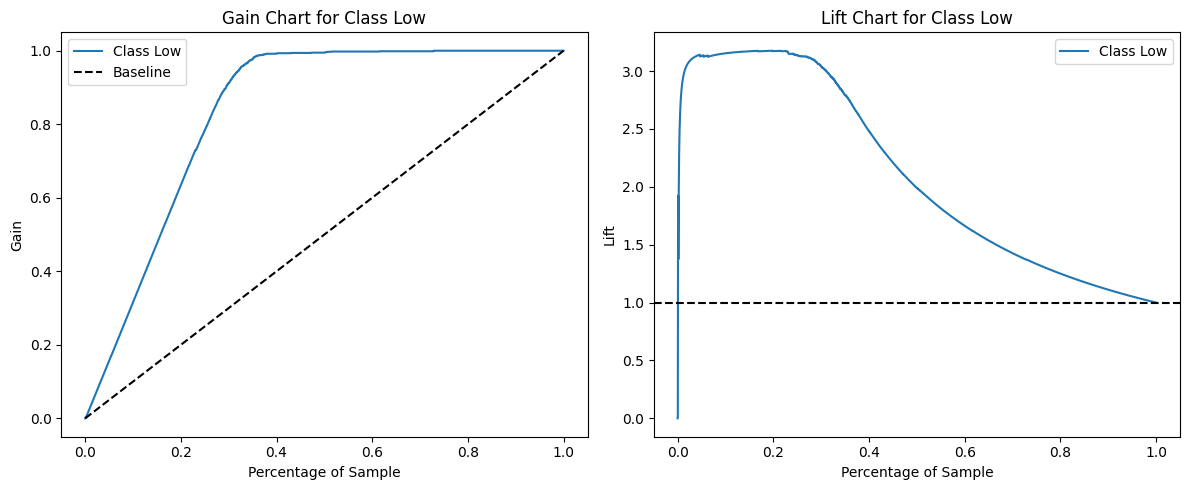

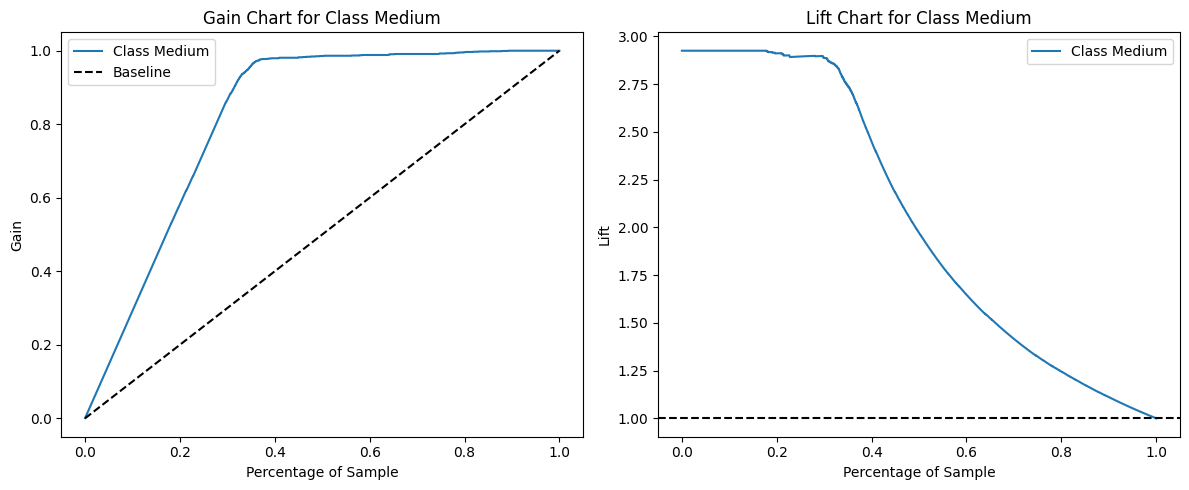

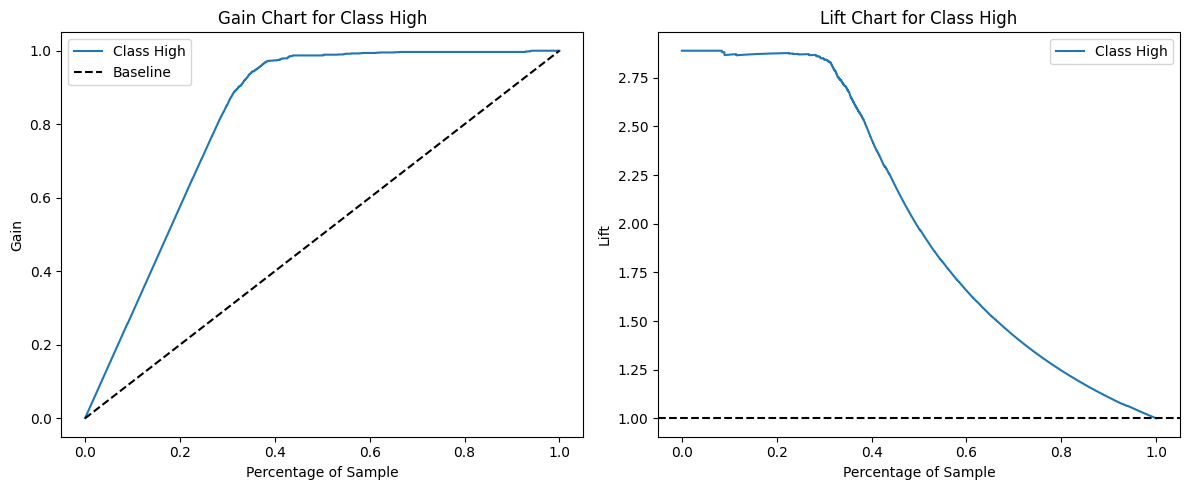

In [67]:
# MLP
MLP_model = final_models['MLP']
# 4) Evaluate on the held-out test set
y_pred_MLP = MLP_model.predict(X_large_test)
y_proba_MLP = MLP_model.predict_proba(X_large_test)

# Accuracy
acc_MLP = accuracy_score(y_large_test, y_pred_MLP)
print(f'Accuracy for MLP: {acc_MLP}')

# ROC-AUC
auc_MLP = plot_multiclass_roc_auc(y_large_test, y_proba_MLP, class_names=['Low', 'Medium', 'High'], title='ROC for MLP')
print(f'ROC-AUC for MLP: {auc_MLP}')

# Confusion Matrix
print('-----------------------------------___Confusion Matrix___MLP-----------------------------------')
ConfusionMatrixDisplay.from_estimator(MLP_model, X_large_test, y_large_test)
plt.show()

# Classification report
MLP_class_reports = classification_report(y_large_test, y_pred_MLP)
print(f'\n MLP classification report:\n', MLP_class_reports)

# KS statistic
MLP_ks_result = multiclass_ks_score(y_large_test, y_proba_MLP, classes=MLP_model.classes_)
print(f'\n MLP K-S statistic:\n', MLP_ks_result)

# Gain & Lift charts
gain_lift_MLP = compute_gain_lift(y_large_test, y_proba_MLP, class_names=['Low', 'Medium', 'High'])

performances['MLP'] = {
    'accuracy': acc_MLP,
    'roc_auc': auc_MLP,
    'classification_report': MLP_class_reports,
    'K-S statistic': MLP_ks_result,
    'gain_lift': gain_lift_MLP
}


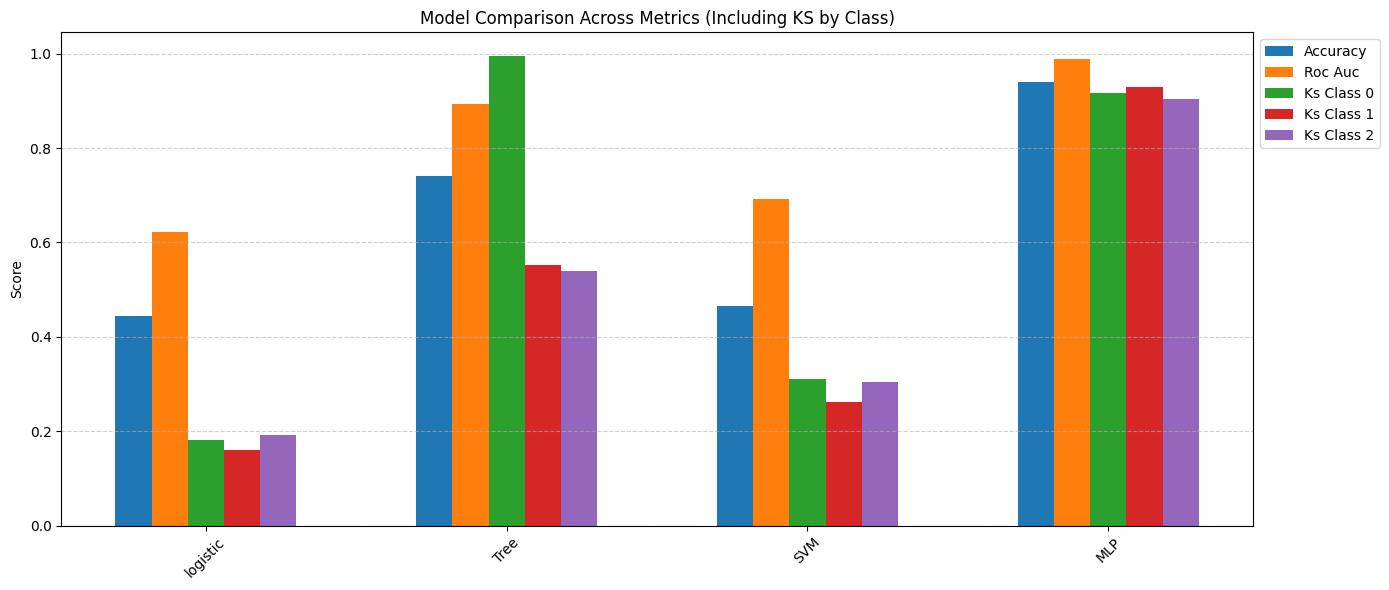

In [68]:
def plot_model_metrics_detailed(performances, class_labels=None):
    models = list(performances.keys())
    if class_labels is None:
        class_labels = ['Class 0', 'Class 1', 'Class 2']  # adjust if needed

    # Define the metrics to extract
    metrics = ['accuracy', 'roc_auc'] + [f'ks_{label}' for label in class_labels]

    # Prepare data structure
    data = {metric: [] for metric in metrics}

    for model in models:
        model_data = performances[model]
        data['accuracy'].append(model_data['accuracy'])
        data['roc_auc'].append(model_data['roc_auc'])

        # KS statistics per class
        for i, label in enumerate(class_labels):
            data[f'ks_{label}'].append(model_data['K-S statistic'][i])

    # Plotting
    x = np.arange(len(models))
    total_bars = len(metrics)
    width = 0.12

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, data[metric], width, label=metric.replace('_', ' ').title())

    ax.set_xticks(x + width * (total_bars - 1) / 2)
    ax.set_xticklabels(models, rotation=45)
    ax.set_ylabel('Score')
    ax.set_title('Model Comparison Across Metrics (Including KS by Class)')
    ax.legend(loc='upper left', bbox_to_anchor=(1,1))
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_model_metrics_detailed(performances)